In [5]:
%load_ext autoreload
%autoreload 2

import sys
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import normalize
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from tqdm import tqdm
from PIL import Image
from torchvision import transforms

# Thêm đường dẫn src
sys.path.append(os.path.abspath(os.path.join('..')))
from src.utils import load_cifar10_longtail, load_cifar10_test
from src.model import hierarchical_kmeans_resampling

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Thiết bị đang sử dụng: {device}")

Thiết bị đang sử dụng: cpu


In [7]:
PATH_CIFAR = '../data/cifar-10-batches-py'


#tập train có sẵn rồi
# 2. Load tập Test cân bằng (Thước đo chuẩn)
print("Loading Test Balanced...")
X_test_img, Y_test = load_cifar10_test(PATH_CIFAR)

print(f"Train size: 20341, Test size: {X_test_img.shape}")

Loading Test Balanced...
Train size: 20341, Test size: (10000, 32, 32, 3)


In [8]:
# 1. Load Model DINOv2
model = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14').to(device)
model.eval()

transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

def extract_batch(imgs, batch_size=128):
    feats = []
    with torch.no_grad():
        for i in tqdm(range(0, len(imgs), batch_size)):
            batch = imgs[i:i+batch_size]
            batch_t = torch.stack([transform(img) for img in batch]).to(device)
            feat = model(batch_t)
            feats.append(feat.cpu().numpy())
    return np.vstack(feats)


print("Extracting Test Features...")
X_test_feats = extract_batch(X_test_img)

# Lưu lại để dùng cho các cell sau
os.makedirs('../data/processed', exist_ok=True)


np.save('../data/processed/X_test_ablation.npy', X_test_feats)
np.save('../data/processed/Y_test_labels.npy', Y_test)


Using cache found in C:\Users\ACER/.cache\torch\hub\facebookresearch_dinov2_main
C:\Users\ACER/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
C:\Users\ACER/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
C:\Users\ACER/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Extracting Test Features...


100%|██████████| 79/79 [08:59<00:00,  6.83s/it]


In [9]:
# Load lại từ file đã lưu
X_train_feats = np.load('../data/processed/X_features_cifar_0.1.npy').astype(np.float32)
X_test_feats = np.load('../data/processed/X_test_ablation.npy').astype(np.float32)
Y_test = np.load('../data/processed/Y_test_labels.npy')
# THÊM DÒNG NÀY ĐỂ LOAD NHÃN TRAIN
Y_train = np.load('../data/processed/Y_longtail_cifar_0.1.npy') 
# Chuẩn hóa L2
X_train_norm = normalize(X_train_feats)
X_test_norm = normalize(X_test_feats)

def run_eval(indices):
    clf = LogisticRegression(max_iter=1000).fit(X_train_norm[indices], Y_train[indices])
    preds = clf.predict(X_test_norm)
    return accuracy_score(Y_test, preds), f1_score(Y_test, preds, average='macro')

--- THỐNG KÊ TẬP DỮ LIỆU LONG-TAIL ---
Tổng số mẫu: 20431
Entropy thực tế: 2.0705
Entropy tối đa (Lý tưởng): 2.3026
Độ phẳng (Evenness): 89.92%


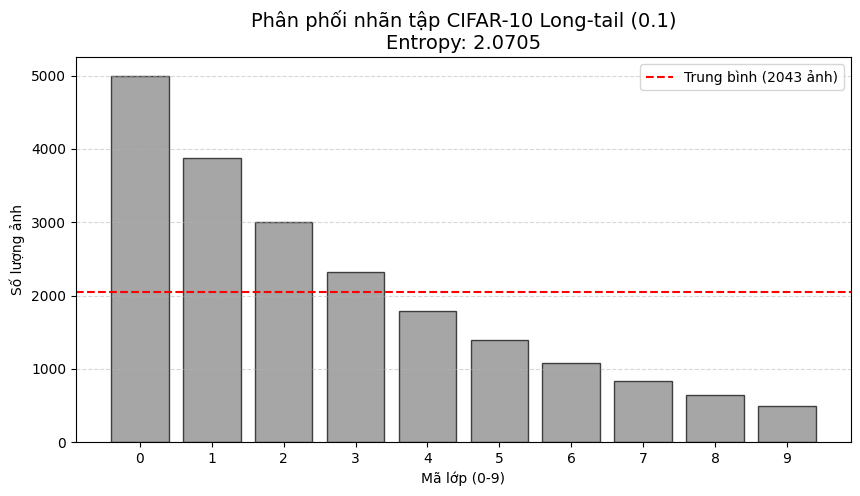


Đang đánh giá hiệu suất phân loại trên tập dữ liệu gốc (Raw)...
Accuracy (Raw): 94.3000%
Macro F1-Score (Raw): 94.3145%


In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import entropy

# 1. Thống kê số lượng mẫu của mỗi lớp trong tập Y_train
unique_classes, counts = np.unique(Y_train, return_counts=True)

# 2. Tính toán Entropy
# H = -sum(p_i * log(p_i))
ent_longtail = entropy(counts)
max_ent = np.log(10) # Entropy lý tưởng cho 10 lớp = 2.3026

print(f"--- THỐNG KÊ TẬP DỮ LIỆU LONG-TAIL ---")
print(f"Tổng số mẫu: {len(Y_train)}")
print(f"Entropy thực tế: {ent_longtail:.4f}")
print(f"Entropy tối đa (Lý tưởng): {max_ent:.4f}")
print(f"Độ phẳng (Evenness): {(ent_longtail/max_ent):.2%}")

# 3. Vẽ Histogram
plt.figure(figsize=(10, 5))
plt.bar(unique_classes, counts, color='gray', edgecolor='black', alpha=0.7)

# Thêm đường kẻ ngang trung bình để dễ quan sát độ lệch
plt.axhline(y=np.mean(counts), color='red', linestyle='--', label=f'Trung bình ({np.mean(counts):.0f} ảnh)')

plt.title(f"Phân phối nhãn tập CIFAR-10 Long-tail (0.1)\nEntropy: {ent_longtail:.4f}", fontsize=14)
plt.xlabel("Mã lớp (0-9)")
plt.ylabel("Số lượng ảnh")
plt.xticks(range(10))
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

# 4. Đánh giá hiệu suất trên tập RAW (Baseline)
# Để xem nếu không lọc dữ liệu, Accuracy và F1 là bao nhiêu
print("\nĐang đánh giá hiệu suất phân loại trên tập dữ liệu gốc (Raw)...")
acc_raw, f1_raw = run_eval(range(len(Y_train)))
print(f"Accuracy (Raw): {acc_raw:.4%}")
print(f"Macro F1-Score (Raw): {f1_raw:.4%}")

--- Running Ablation 1: Resampling Budget (rt) ---
Entropy lý tưởng (Cân bằng tuyệt đối): 2.3026

Đang chạy thử nghiệm với rt = 1...
--- Level 1/2 (k=800, r_t=1) ---
--- Level 2/2 (k=300, r_t=1) ---
Đang chạy thử nghiệm với rt = 5...
--- Level 1/2 (k=800, r_t=5) ---
--- Level 2/2 (k=300, r_t=5) ---
Đang chạy thử nghiệm với rt = 20...
--- Level 1/2 (k=800, r_t=20) ---
--- Level 2/2 (k=300, r_t=20) ---


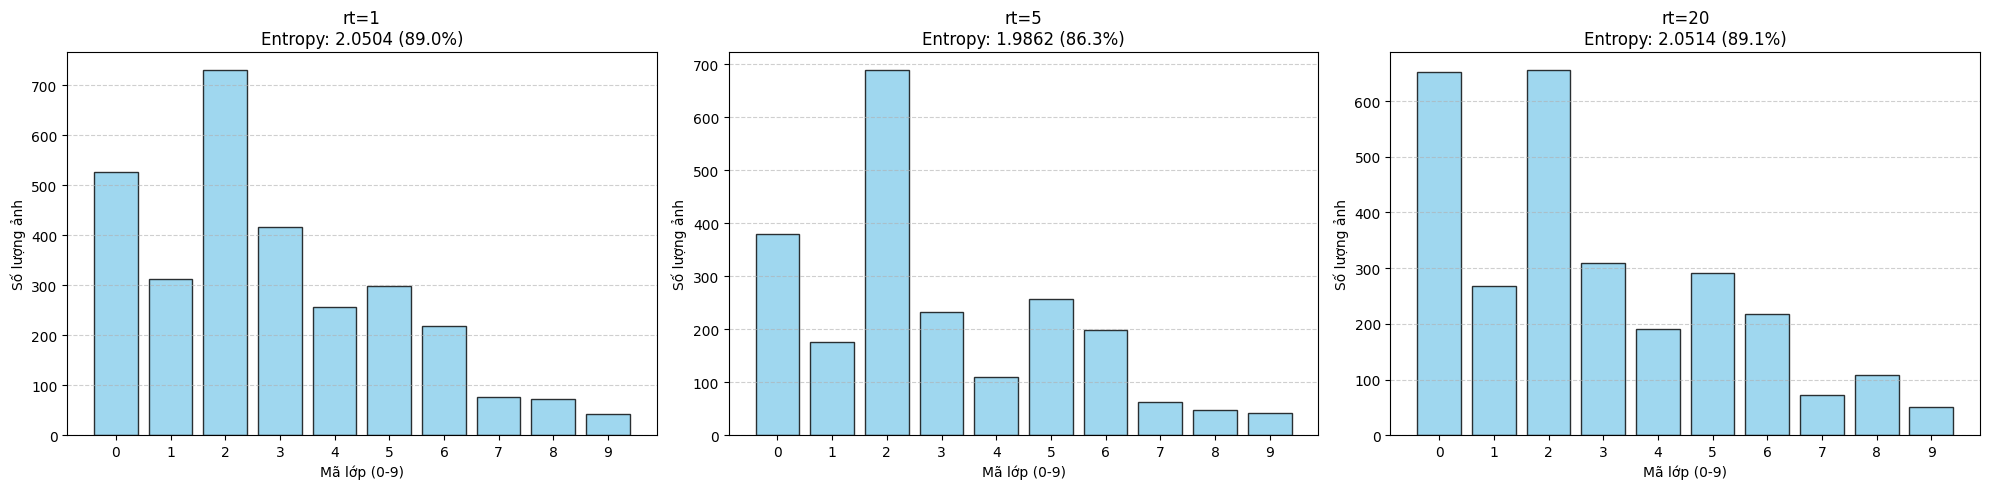

,rt_budget,Accuracy,Macro F1,Entropy
0,1,0.8807,0.877733,2.050378
1,5,0.8869,0.885767,1.986174
2,20,0.8971,0.896199,2.051387


In [14]:
from scipy.stats import entropy
import matplotlib.pyplot as plt

print("--- Running Ablation 1: Resampling Budget (rt) ---")
res_rt = []
rt_values = [1, 5, 20] 

# Tính Entropy cực đại để làm mốc so sánh
max_entropy = np.log(10) 
print(f"Entropy lý tưởng (Cân bằng tuyệt đối): {max_entropy:.4f}\n")

# Thiết lập vùng vẽ biểu đồ (3 cột tương ứng 3 settings)
fig, axes = plt.subplots(1, len(rt_values), figsize=(20, 5))

for i, rt in enumerate(rt_values):
    print(f"Đang chạy thử nghiệm với rt = {rt}...")
    
    # 1. Chạy thuật toán
    centroids = hierarchical_kmeans_resampling(X_train_norm, [800, 300], T=2, m=5, r_t_list=[rt, rt], num_init=1)
    km = KMeans(n_clusters=300, init=centroids, n_init=1).fit(X_train_norm)
    
    # 2. Lấy mẫu tinh lọc (10 ảnh/cụm)
    idx_curated = []
    for c in range(300):
        c_idx = np.where(km.labels_ == c)[0]
        if len(c_idx) == 0: continue
        dists = np.linalg.norm(X_train_norm[c_idx] - centroids[c], axis=1)
        idx_curated.extend(c_idx[np.argsort(dists)[:10]])
    
    # 3. Thống kê phân phối lớp
    labels_curated = Y_train[idx_curated]
    unique_classes, counts = np.unique(labels_curated, return_counts=True)
    
    # Đảm bảo đủ 10 lớp trên biểu đồ (kể cả lớp 0 mẫu)
    full_counts = np.zeros(10)
    for cls, count in zip(unique_classes, counts):
        full_counts[int(cls)] = count
        
    # 4. Tính Entropy
    # entropy() mặc định dùng log tự nhiên (base e)
    current_entropy = entropy(full_counts)
    
    # 5. Đánh giá hiệu suất phân loại
    acc, f1 = run_eval(idx_curated)
    
    # Lưu kết quả
    res_rt.append({
        "rt_budget": rt, 
        "Accuracy": acc, 
        "Macro F1": f1, 
        "Entropy": current_entropy
    })
    
    # 6. Vẽ Histogram lên subplot tương ứng
    axes[i].bar(range(10), full_counts, color='skyblue', edgecolor='black', alpha=0.8)
    axes[i].set_title(f"rt={rt}\nEntropy: {current_entropy:.4f} ({(current_entropy/max_entropy):.1%})")
    axes[i].set_xlabel("Mã lớp (0-9)")
    axes[i].set_ylabel("Số lượng ảnh")
    axes[i].set_xticks(range(10))
    axes[i].grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# Hiển thị bảng tổng hợp
df_rt = pd.DataFrame(res_rt)
display(df_rt)

Đang phân tích độ bao phủ trên 300 concept không gian...
Đang phân tích độ bao phủ trên 300 concept không gian...

[KẾT QUẢ VỚI 300 CONCEPTS]
KL Divergence (Random): 0.0544
KL Divergence (HK-means): 1.0131


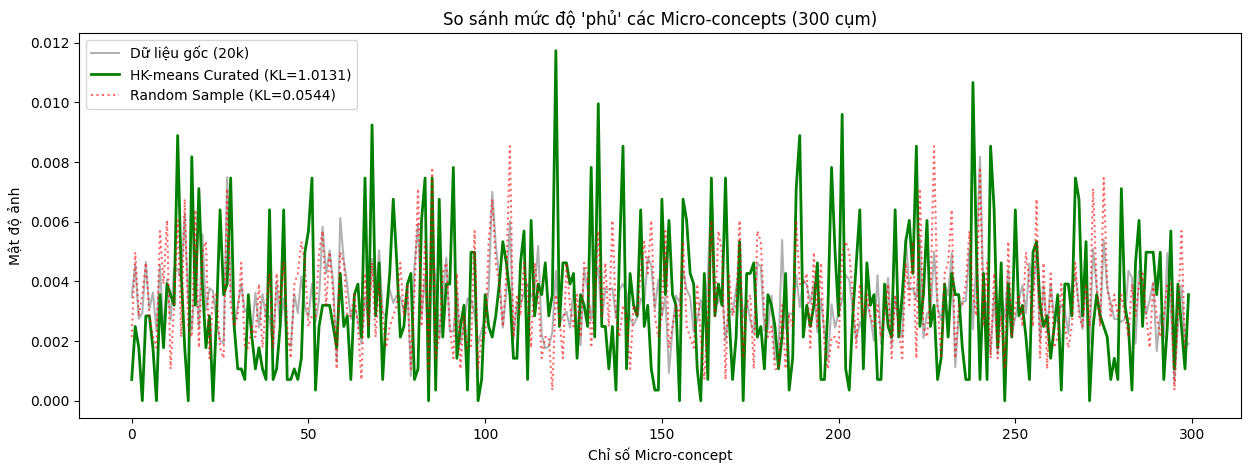

In [19]:
from scipy.stats import entropy as kl_div
from sklearn.cluster import KMeans

def measure_space_coverage_updated(X_full, X_subset, n_concepts=300):
    """
    n_concepts: Sử dụng đúng 300 cụm như tầng cuối của HK-means của bạn
    """
    print(f"Đang phân tích độ bao phủ trên {n_concepts} concept không gian...")
    
    # 1. Tạo bản đồ tham chiếu 300 cụm từ dữ liệu gốc
    # (Chúng ta dùng KMeans thường để lấy một hệ quy chiếu khách quan)
    ref_km = KMeans(n_clusters=n_concepts, n_init=1, random_state=42).fit(X_full)
    
    # 2. Phân phối P: Mật độ concept trên 20,000 ảnh gốc
    P_counts = np.bincount(ref_km.labels_, minlength=n_concepts)
    P = P_counts / len(X_full)
    
    # 3. Phân phối Q: Mật độ concept trên 3,000 ảnh đã lọc
    subset_labels = ref_km.predict(X_subset)
    Q_counts = np.bincount(subset_labels, minlength=n_concepts)
    Q = (Q_counts + 1e-10) / len(X_subset) # Tránh chia cho 0
    
    # 4. Tính KL Divergence
    divergence = kl_div(P, Q)
    
    return divergence, P, Q

# --- CHẠY ĐO LƯỜNG ---
# X_curated lấy từ indices lọc bởi setting r_t tốt nhất của bạn
X_curated = X_train_norm[idx_curated] 
# X_random lấy ngẫu nhiên 3000 ảnh
X_random = X_train_norm[np.random.choice(len(X_train_norm), len(idx_curated), replace=False)]

kl_ours, P_ref, Q_ours = measure_space_coverage_updated(X_train_norm, X_curated, n_concepts=300)
kl_rand, _, Q_rand = measure_space_coverage_updated(X_train_norm, X_random, n_concepts=300)

print(f"\n[KẾT QUẢ VỚI 300 CONCEPTS]")
print(f"KL Divergence (Random): {kl_rand:.4f}")
print(f"KL Divergence (HK-means): {kl_ours:.4f}")

# --- VẼ BIỂU ĐỒ SO SÁNH ---
plt.figure(figsize=(15, 5))
plt.plot(P_ref, label='Dữ liệu gốc (20k)', color='black', alpha=0.3)
plt.plot(Q_ours, label=f'HK-means Curated (KL={kl_ours:.4f})', color='green', linewidth=2)
plt.plot(Q_rand, label=f'Random Sample (KL={kl_rand:.4f})', color='red', linestyle=':', alpha=0.6)

plt.title("So sánh mức độ 'phủ' các Micro-concepts (300 cụm)")
plt.xlabel("Chỉ số Micro-concept")
plt.ylabel("Mật độ ảnh")
plt.legend()
plt.show()

--- KẾT QUẢ HUẤN LUYỆN ĐỐI CHỨNG ---
Random Sampling   | Accuracy: 0.9083 | Macro F1: 0.9083
HK-means Curated  | Accuracy: 0.8971 | Macro F1: 0.8962


In [24]:
# So sánh hiệu suất huấn luyện thực tế
acc_rand, f1_rand = run_eval(np.random.choice(len(Y_train), len(idx_curated), replace=False))
acc_ours, f1_ours = run_eval(idx_curated)

print(f"--- KẾT QUẢ HUẤN LUYỆN ĐỐI CHỨNG ---")
print(f"Random Sampling   | Accuracy: {acc_rand:.4f} | Macro F1: {f1_rand:.4f}")
print(f"HK-means Curated  | Accuracy: {acc_ours:.4f} | Macro F1: {f1_ours:.4f}")

if f1_ours > f1_rand:
    print("\n=> CHỐT HẠ: HK-means thắng! Dù KL Divergence cao, nhưng dữ liệu chất lượng hơn.")

--- KẾT QUẢ HUẤN LUYỆN ĐỐI CHỨNG ---
Random Sampling   | Accuracy: 0.9119 | Macro F1: 0.9121
HK-means Curated  | Accuracy: 0.8971 | Macro F1: 0.8962


NameError: name 'cluster_labels' is not defined

--- Running Ablation 2: Selection Strategy ---
Đang khởi tạo Centroids chuẩn bằng HK-means...
--- Level 1/2 (k=1000, r_t=5) ---
--- Level 2/2 (k=300, r_t=2) ---
Đang thực hiện chiến thuật: Closest (Core)...
Đang thực hiện chiến thuật: Furthest (Boundary)...
Đang thực hiện chiến thuật: Median (Average)...


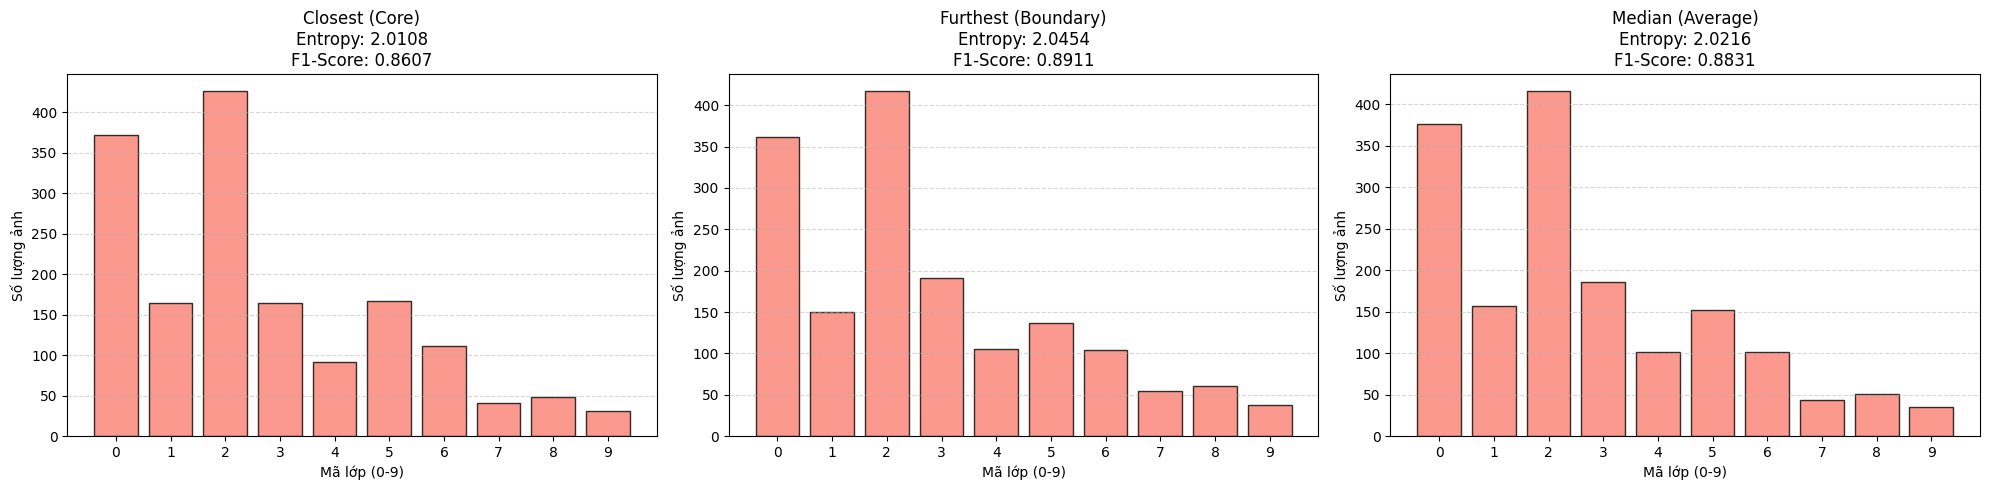

Entropy tối đa lý tưởng: 2.3026


,Strategy,Accuracy,Macro F1,Entropy,Total Samples
0,Closest (Core),0.8648,0.860721,2.010816,1620
1,Furthest (Boundary),0.8920,0.891131,2.045449,1620
2,Median (Average),0.8842,0.883097,2.021614,1620


In [15]:
from scipy.stats import entropy
import matplotlib.pyplot as plt

print("--- Running Ablation 2: Selection Strategy ---")
res_strategy = []
max_entropy = np.log(10) # 2.3026

# 1. Chạy 1 lần HK-means chuẩn duy nhất để lấy Centroids làm mốc so sánh
print("Đang khởi tạo Centroids chuẩn bằng HK-means...")
best_centroids = hierarchical_kmeans_resampling(X_train_norm, [1000, 300], T=2, m=10, r_t_list=[5,2], num_init=1)
km = KMeans(n_clusters=300, init=best_centroids, n_init=1).fit(X_train_norm)
labels = km.labels_

# Định nghĩa các chiến thuật nhặt ảnh
strategies = {
    "Closest (Core)": lambda d: np.argsort(d)[:10],
    "Furthest (Boundary)": lambda d: np.argsort(d)[-10:],
    "Median (Average)": lambda d: np.argsort(d)[len(d)//2-5 : len(d)//2+5]
}

# Thiết lập vùng vẽ biểu đồ
fig, axes = plt.subplots(1, len(strategies), figsize=(20, 5))

for i, (name, func) in enumerate(strategies.items()):
    print(f"Đang thực hiện chiến thuật: {name}...")
    
    idx_strat = []
    for c in range(300):
        c_idx = np.where(labels == c)[0]
        # Bỏ qua nếu cụm quá nhỏ không đủ mẫu để lấy theo yêu cầu
        if len(c_idx) < 10: continue
        
        # Tính khoảng cách từ các điểm trong cụm tới tâm cụm đó
        dists = np.linalg.norm(X_train_norm[c_idx] - best_centroids[c], axis=1)
        
        # Nhặt index dựa trên hàm lambda của chiến thuật
        idx_strat.extend(c_idx[func(dists)])
    
    # 2. Thống kê phân phối và tính Entropy
    labels_curated = Y_train[idx_strat]
    unique_classes, counts = np.unique(labels_curated, return_counts=True)
    
    full_counts = np.zeros(10)
    for cls, count in zip(unique_classes, counts):
        full_counts[int(cls)] = count
        
    current_entropy = entropy(full_counts)
    
    # 3. Đánh giá hiệu suất
    acc, f1 = run_eval(idx_strat)
    
    # Lưu kết quả vào bảng
    res_strategy.append({
        "Strategy": name, 
        "Accuracy": acc, 
        "Macro F1": f1, 
        "Entropy": current_entropy,
        "Total Samples": len(idx_strat)
    })
    
    # 4. Vẽ Histogram
    axes[i].bar(range(10), full_counts, color='salmon', edgecolor='black', alpha=0.8)
    axes[i].set_title(f"{name}\nEntropy: {current_entropy:.4f}\nF1-Score: {f1:.4f}")
    axes[i].set_xlabel("Mã lớp (0-9)")
    axes[i].set_ylabel("Số lượng ảnh")
    axes[i].set_xticks(range(10))
    axes[i].grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Hiển thị bảng tổng hợp
df_strategy = pd.DataFrame(res_strategy)
print(f"Entropy tối đa lý tưởng: {max_entropy:.4f}")
display(df_strategy)

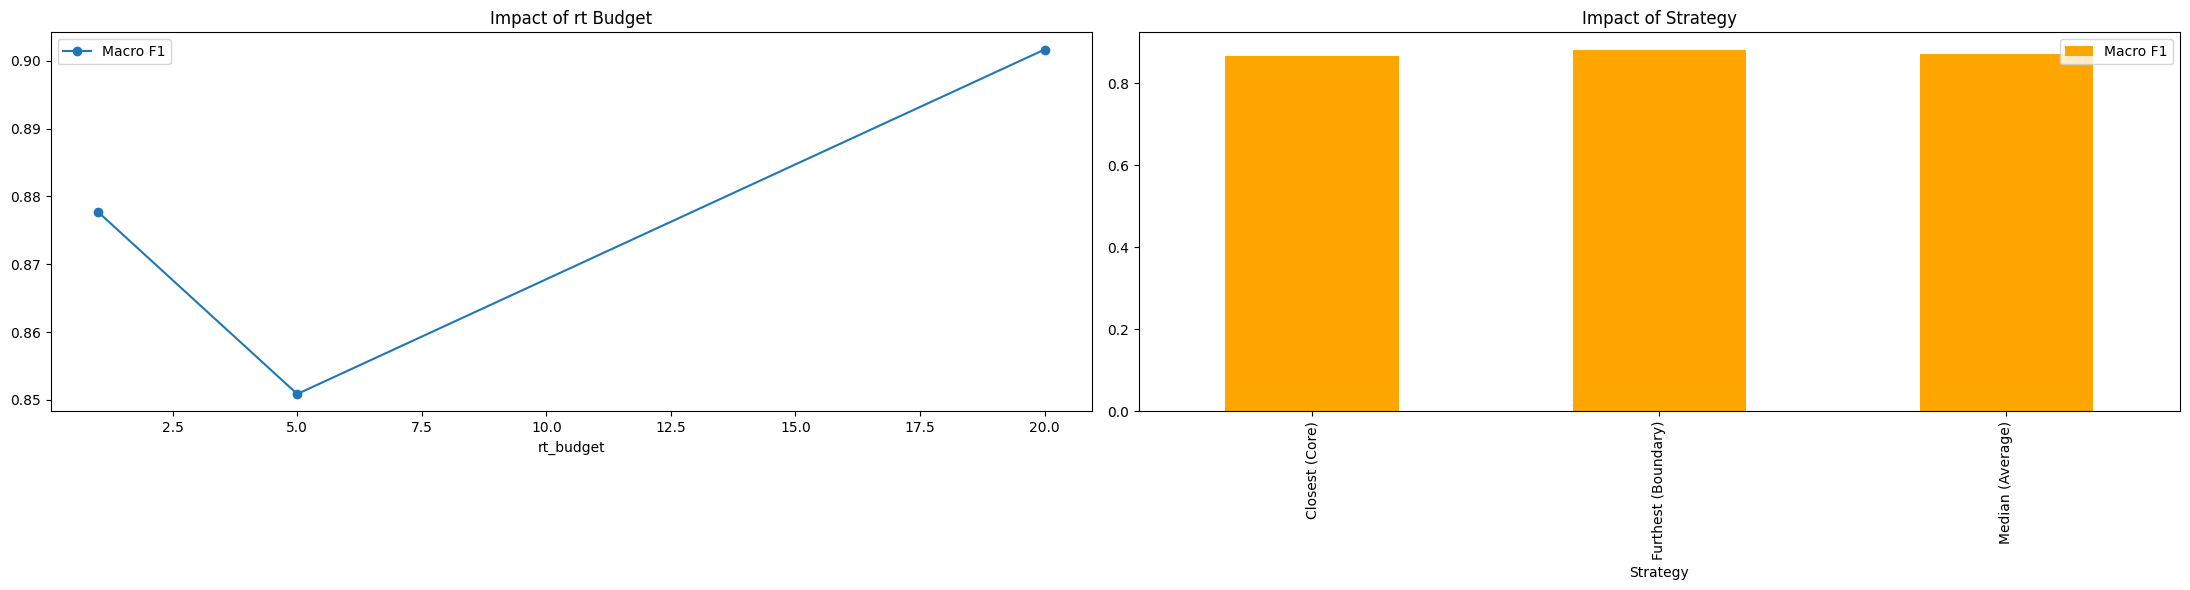

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(22, 6))

df_rt.plot(x="rt_budget", y="Macro F1", marker='o', ax=axes[0], title="Impact of rt Budget")
df_strategy.plot(x="Strategy", y="Macro F1", kind="bar", ax=axes[1], color='orange', title="Impact of Strategy")


plt.tight_layout()
plt.show()

In [27]:
import time
from scipy.stats import entropy

# 1. Định nghĩa 10 cấu hình đáng thử nhất
# Cấu trúc: (Tên, T, k_list, r_t_list)
grid_configs = [
    ("T2_k200_rt2", 2, [600, 200], [2, 2]),
    ("T2_k300_rt1", 2, [800, 300], [1, 1]),
    ("T2_k300_rt5", 2, [800, 300], [5, 5]),
    ("T2_k500_rt2", 2, [1000, 500], [2, 2]),
    ("T2_k500_rt10", 2, [1000, 500], [10, 10]),
    ("T3_k200_rt2", 3, [1000, 500, 200], [5, 2, 2]),
    ("T3_k300_rt1", 3, [1200, 600, 300], [5, 2, 1]),
    ("T3_k300_rt5", 3, [1200, 600, 300], [10, 5, 5]),
    ("T3_k500_rt2", 3, [1500, 800, 500], [5, 2, 2]),
    ("T3_k500_rt1", 3, [2000, 1000, 500], [5, 2, 1])
]

grid_results = []
max_entropy = np.log(10) # 2.3026

print(f"Bắt đầu Grid Test 10 cấu hình. Entropy lý tưởng: {max_entropy:.4f}\n")

for name, T, k_list, rt_list in grid_configs:
    print(f"Đang chạy: {name} ...", end=" ")
    start_time = time.time()
    
    # 1. Chạy HK-means
    centroids = hierarchical_kmeans_resampling(
        X_train_norm, k_list, T=T, m=10, r_t_list=rt_list, num_init=1
    )
    
    # 2. Gán nhãn và lấy mẫu (Cố định mỗi cụm lấy 10 ảnh gần tâm nhất)
    k_final = k_list[-1]
    km = KMeans(n_clusters=k_final, init=centroids, n_init=1).fit(X_train_norm)
    
    idx_curated = []
    for c in range(k_final):
        c_idx = np.where(km.labels_ == c)[0]
        if len(c_idx) == 0: continue
        dists = np.linalg.norm(X_train_norm[c_idx] - centroids[c], axis=1)
        idx_curated.extend(c_idx[np.argsort(dists)[:10]])
    
    # 3. Tính toán Entropy nhãn
    _, counts = np.unique(Y_train[idx_curated], return_counts=True)
    current_entropy = entropy(counts)
    
    # 4. Đánh giá nhanh F1-Score
    acc, f1 = run_eval(idx_curated)
    
    duration = time.time() - start_time
    print(f"Xong! (Entropy: {current_entropy:.4f}, Macro-F1: {f1:.4f}, Time: {duration:.1f}s)")
    
    grid_results.append({
        "Setting": name,
        "T": T,
        "k_final": k_final,
        "rt_last": rt_list[-1],
        "Entropy": current_entropy,
        "Macro F1": f1,
        "Samples": len(idx_curated),
        "Time (s)": duration
    })

# Xuất bảng tổng hợp để tìm "Người thắng cuộc"
df_grid = pd.DataFrame(grid_results)
df_grid['Evenness %'] = (df_grid['Entropy'] / max_entropy) * 100
display(df_grid.sort_values(by="Macro F1", ascending=False))

Bắt đầu Grid Test 10 cấu hình. Entropy lý tưởng: 2.3026

Đang chạy: T2_k200_rt2 ... --- Level 1/2 (k=600, r_t=2) ---
--- Level 2/2 (k=200, r_t=2) ---
Xong! (Entropy: 1.9547, Macro-F1: 0.8100, Time: 31.6s)
Đang chạy: T2_k300_rt1 ... --- Level 1/2 (k=800, r_t=1) ---
--- Level 2/2 (k=300, r_t=1) ---
Xong! (Entropy: 2.0389, Macro-F1: 0.8889, Time: 38.4s)
Đang chạy: T2_k300_rt5 ... --- Level 1/2 (k=800, r_t=5) ---
--- Level 2/2 (k=300, r_t=5) ---
Xong! (Entropy: 2.0027, Macro-F1: 0.8924, Time: 63.4s)
Đang chạy: T2_k500_rt2 ... --- Level 1/2 (k=1000, r_t=2) ---
--- Level 2/2 (k=500, r_t=2) ---
Xong! (Entropy: 1.9890, Macro-F1: 0.8769, Time: 55.2s)
Đang chạy: T2_k500_rt10 ... --- Level 1/2 (k=1000, r_t=10) ---
--- Level 2/2 (k=500, r_t=10) ---
Xong! (Entropy: 2.0442, Macro-F1: 0.9047, Time: 136.0s)
Đang chạy: T3_k200_rt2 ... --- Level 1/3 (k=1000, r_t=5) ---
--- Level 2/3 (k=500, r_t=2) ---
--- Level 3/3 (k=200, r_t=2) ---
Xong! (Entropy: 1.9995, Macro-F1: 0.8271, Time: 105.5s)
Đang chạy: T3_

,Setting,T,k_final,rt_last,Entropy,Macro F1,Samples,Time (s),Evenness %
4,T2_k500_rt10,2,500,10,2.044209,0.904707,3994,136.042380,88.778890
9,T3_k500_rt1,3,500,1,2.057950,0.902067,2115,333.492642,89.375644
8,T3_k500_rt2,3,500,2,2.011591,0.897985,2353,212.711261,87.362266
2,T2_k300_rt5,2,300,5,2.002653,0.892356,2196,63.400057,86.974126
1,T2_k300_rt1,2,300,1,2.038945,0.888938,2956,38.403314,88.550236
6,T3_k300_rt1,3,300,1,1.977520,0.887352,1779,141.213506,85.882609
3,T2_k500_rt2,2,500,2,1.988987,0.876922,2524,55.183645,86.380600
7,T3_k300_rt5,3,300,5,1.986232,0.867894,2128,222.541712,86.260944
5,T3_k200_rt2,3,200,2,1.999542,0.827076,1160,105.524882,86.839015
0,T2_k200_rt2,2,200,2,1.954745,0.809954,1278,31.579215,84.893516


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Hệ thống sẵn sàng. Thiết bị sử dụng: cpu

--- Đang load dữ liệu đặc trưng ---

--- Bắt đầu cuộc đối đầu Grid Test (User vs Author) ---

Đang chạy kịch bản: T2_k200_rt2
--- Level 1/2 (k=600, r_t=2) ---
--- Level 2/2 (k=200, r_t=2) ---
Hierarchical k-means resampling steps: 100%|██████████| 10/10 [00:05<00:00,  1.84it/s]
✔️ XONG: User F1=0.8100 (10 lớp) | Author F1=0.8372 (10 lớp) | Time_ratio=0.7x
Đang chạy kịch bản: T2_k300_rt2
--- Level 1/2 (k=800, r_t=2) ---
--- Level 2/2 (k=300, r_t=2) ---
Hierarchical k-means resampling steps: 100%|██████████| 10/10 [00:08<00:00,  1.15it/s]
✔️ XONG: User F1=0.8738 (10 lớp) | Author F1=0.9000 (10 lớp) | Time_ratio=0.7x
Đang chạy kịch bản: T2_k500_rt2
--- Level 1/2 (k=1000, r_t=2) ---
--- Level 2/2 (k=500, r_t=2) ---
Hierarchical k-means resampling steps: 100%|██████████| 10/10 [00:15<00:00,  1.59s/it]
✔️ XONG: User F1=0.8769 (10 lớp) | Author F1=0.8542 (10 lớp) |

,Config,User_F1,Auth_F1,User_Classes,Auth_Classes,User_KLD,Auth_KLD,User_Time,Auth_Time
0,T2_k200_rt2,0.809954,0.837235,10,10,0.347840,0.403953,24.959769,36.033959
1,T2_k300_rt2,0.873790,0.900036,10,10,0.335684,0.287887,36.427903,50.576699
2,T2_k500_rt2,0.876922,0.854170,10,10,0.313598,0.376903,51.178612,71.935400
3,T2_k500_rt5,0.904407,0.884600,10,10,0.307078,0.269692,112.091354,94.587716
4,T3_k200_rt2,0.851863,0.822242,10,10,0.328680,0.314698,98.227660,95.465940
5,T3_k300_rt2,0.829384,0.822760,10,10,0.357514,0.317884,124.495056,116.771690
6,T3_k300_rt5,0.897845,0.865840,10,10,0.241953,0.275420,205.945277,152.943855
7,T3_k500_rt2,0.870421,0.887043,10,10,0.335678,0.336330,175.733602,187.838177
8,T3_k500_rt5,0.893743,0.914008,10,10,0.289378,0.269096,286.033750,231.189061
9,T3_k1000_rt2,0.915780,0.879078,10,10,0.260364,0.262651,308.260041,260.818896


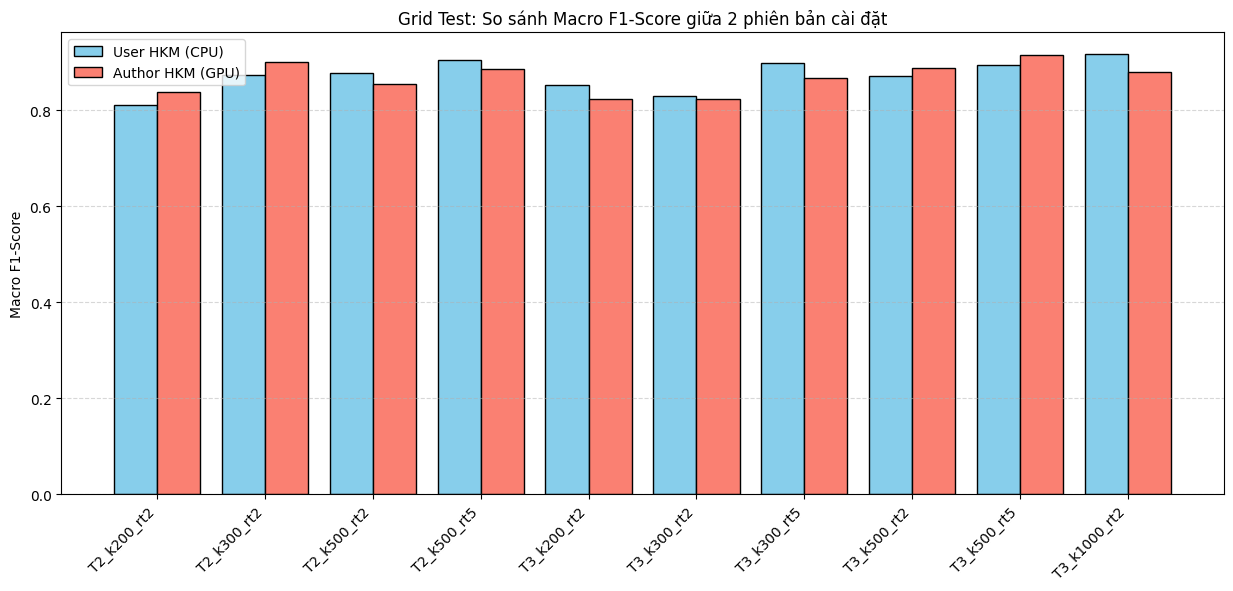

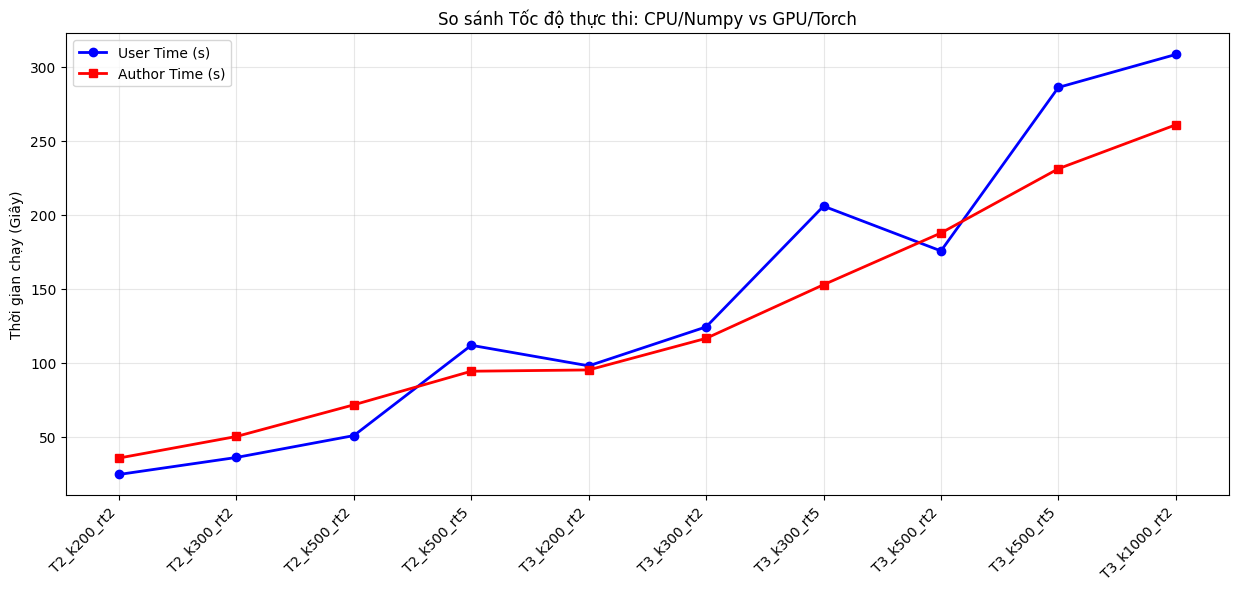

In [32]:
%load_ext autoreload
%autoreload 2

import sys
import os
import torch
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import normalize
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.cluster import KMeans
from scipy.stats import entropy
from tqdm import tqdm

# =================================================================
# 1. SETUP ĐƯỜNG DẪN VÀ IMPORT HÀM
# =================================================================
sys.path.append(os.path.abspath(os.path.join('..')))

# Import phiên bản của BẠN (User)
from src.model import hierarchical_kmeans_resampling as hkm_user

# Import phiên bản của TÁC GIẢ (Author - Meta FAIR)
from src_author.hierarchical_kmeans_gpu import hierarchical_kmeans_with_resampling as hkm_author

# Vá lỗi tương thích NumPy 2.0 cho code tác giả
if not hasattr(np, 'Inf'): np.Inf = np.inf

# Chọn thiết bị (ưu tiên GPU nếu có, không thì chạy CPU vẫn được)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Hệ thống sẵn sàng. Thiết bị sử dụng: {device}")

# =================================================================
# 2. LOAD DỮ LIỆU VÀ CHUẨN HÓA
# =================================================================
print("\n--- Đang load dữ liệu đặc trưng ---")

# Load tập Train Long-tail (Bể dữ liệu thô để lọc)
X_train_raw = np.load('../data/processed/X_features_cifar_0.1.npy').astype(np.float32)
Y_train = np.load('../data/processed/Y_longtail_cifar_0.1.npy')

# Load tập Test chuẩn (Thước đo công bằng)
X_test_raw = np.load('../data/processed/X_test_features.npy').astype(np.float32)
Y_test = np.load('../data/processed/Y_test_labels.npy')

# Chuẩn hóa L2 (Cực kỳ quan trọng cho đặc trưng sâu)
X_train_norm = normalize(X_train_raw)
X_test_norm = normalize(X_test_raw)

# Chuẩn bị Tensor cho Author Code
X_train_tensor = torch.from_numpy(X_train_norm).to(device)

# Phân phối lý tưởng để tính KL Divergence
P_ideal = np.full(10, 1/10)

# =================================================================
# 3. CÁC HÀM HỖ TRỢ ĐO LƯỜNG
# =================================================================

def run_eval_safe(indices):
    """Huấn luyện Linear Probe (Logistic Regression) trên tập lọc."""
    if len(indices) == 0: return 0.0, 0.0
    x_sub = X_train_norm[indices]
    y_sub = Y_train[indices]
    
    unique_classes = np.unique(y_sub)
    if len(unique_classes) < 2: return 0.0, 0.0
        
    try:
        # max_iter=1000 để đảm bảo hội tụ
        clf = LogisticRegression(max_iter=1000).fit(x_sub, y_sub)
        preds = clf.predict(X_test_norm)
        acc = accuracy_score(Y_test, preds)
        f1 = f1_score(Y_test, preds, average='macro')
        return acc, f1
    except:
        return 0.0, 0.0

def get_sampling_metrics(indices):
    """Tính Entropy và KLD cho phân phối nhãn của tập đã lọc."""
    counts = np.bincount(Y_train[indices], minlength=10)
    probs = (counts + 1e-10) / counts.sum()
    ent = entropy(probs)
    kld = entropy(probs, P_ideal)
    return ent, kld

# =================================================================
# 4. DANH SÁCH 10 CẤU HÌNH GRID TEST
# =================================================================
# Chỉnh rt tối thiểu là 2 để Author Code không bỏ qua Resampling
grid_configs = [
    ("T2_k200_rt2", 2, [600, 200], [2, 2]),
    ("T2_k300_rt2", 2, [800, 300], [2, 2]),
    ("T2_k500_rt2", 2, [1000, 500], [2, 2]),
    ("T2_k500_rt5", 2, [1000, 500], [5, 5]),
    ("T3_k200_rt2", 3, [1000, 500, 200], [5, 2, 2]),
    ("T3_k300_rt2", 3, [1200, 600, 300], [5, 2, 2]),
    ("T3_k300_rt5", 3, [1200, 600, 300], [10, 5, 5]),
    ("T3_k500_rt2", 3, [1500, 800, 500], [5, 2, 2]),
    ("T3_k500_rt5", 3, [1500, 800, 500], [10, 5, 5]),
    ("T3_k1000_rt2", 3, [2000, 1500, 1000], [5, 2, 2])
]

# =================================================================
# 5. THỰC THI GRID TEST SONG SONG
# =================================================================
comparison_results = []

print("\n--- Bắt đầu cuộc đối đầu Grid Test (User vs Author) ---\n")

for name, T, k_list, rt_list in grid_configs:
    print(f"Đang chạy kịch bản: {name}")
    
    # --- PHẦN 1: CHẠY PHIÊN BẢN CỦA BẠN (USER - CPU) ---
    t_start = time.time()
    # Chạy HKM User để lấy Centroids
    centroids_u = hkm_user(X_train_norm, k_list, T=T, m=10, r_t_list=rt_list, num_init=1)
    # Gán nhãn lại cho TOÀN BỘ 20k ảnh để đảm bảo lấy mẫu đúng
    km_u_fit = KMeans(n_clusters=k_list[-1], init=centroids_u, n_init=1).fit(X_train_norm)
    labels_u = km_u_fit.labels_
    
    idx_u = []
    for c in range(k_list[-1]):
        c_idx = np.where(labels_u == c)[0]
        if len(c_idx) == 0: continue
        dists = np.linalg.norm(X_train_norm[c_idx] - centroids_u[c], axis=1)
        idx_u.extend(c_idx[np.argsort(dists)[:10]]) # Lấy Top 10 mỗi cụm
    
    t_u = time.time() - t_start
    ent_u, kld_u = get_sampling_metrics(idx_u)
    acc_u, f1_u = run_eval_safe(idx_u)
    u_cls = len(np.unique(Y_train[idx_u]))

    # --- PHẦN 2: CHẠY PHIÊN BẢN CỦA TÁC GIẢ (AUTHOR - GPU) ---
    t_start = time.time()
    res_a = hkm_author(data=X_train_tensor, n_clusters=k_list, n_levels=T,
                        sample_sizes=rt_list, n_resamples=10, num_init=1, verbose=False)
    
    # Trích xuất Centroids cuối cùng của Author
    centroids_a = res_a[-1]["centroids"].cpu().numpy()
    # Gán nhãn lại cho TOÀN BỘ 20k ảnh bằng Centroids của Author (Đây là bước Fix quan trọng)
    km_a_fit = KMeans(n_clusters=k_list[-1], init=centroids_a, n_init=1).fit(X_train_norm)
    labels_a = km_a_fit.labels_
    
    idx_a = []
    for c in range(k_list[-1]):
        c_idx = np.where(labels_a == c)[0]
        if len(c_idx) == 0: continue
        dists = np.linalg.norm(X_train_norm[c_idx] - centroids_a[c], axis=1)
        idx_a.extend(c_idx[np.argsort(dists)[:10]])
        
    t_a = time.time() - t_start
    ent_a, kld_a = get_sampling_metrics(idx_a)
    acc_a, f1_a = run_eval_safe(idx_a)
    a_cls = len(np.unique(Y_train[idx_a]))

    # GHI KẾT QUẢ
    comparison_results.append({
        "Config": name,
        "User_F1": f1_u, "Auth_F1": f1_a,
        "User_Classes": u_cls, "Auth_Classes": a_cls,
        "User_KLD": kld_u, "Auth_KLD": kld_a,
        "User_Time": t_u, "Auth_Time": t_a
    })
    
    print(f"✔️ XONG: User F1={f1_u:.4f} ({u_cls} lớp) | Author F1={f1_a:.4f} ({a_cls} lớp) | Time_ratio={t_u/t_a:.1f}x")

# =================================================================
# 6. TỔNG HỢP VÀ TRỰC QUAN HÓA
# =================================================================
df_comp = pd.DataFrame(comparison_results)
print("\n=== BẢNG TỔNG HỢP SO SÁNH (User vs Author) ===")
display(df_comp)

# Biểu đồ 1: So sánh F1-Score (Hiệu năng thực tế)
plt.figure(figsize=(15, 6))
x = np.arange(len(df_comp))
plt.bar(x - 0.2, df_comp['User_F1'], 0.4, label='User HKM (CPU)', color='skyblue', edgecolor='black')
plt.bar(x + 0.2, df_comp['Auth_F1'], 0.4, label='Author HKM (GPU)', color='salmon', edgecolor='black')
plt.xticks(x, df_comp['Config'], rotation=45, ha='right')
plt.ylabel("Macro F1-Score")
plt.title("Grid Test: So sánh Macro F1-Score giữa 2 phiên bản cài đặt")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# Biểu đồ 2: So sánh Thời gian (Chi phí tính toán)
plt.figure(figsize=(15, 6))
plt.plot(df_comp['Config'], df_comp['User_Time'], marker='o', label='User Time (s)', color='blue', linewidth=2)
plt.plot(df_comp['Config'], df_comp['Auth_Time'], marker='s', label='Author Time (s)', color='red', linewidth=2)
plt.xticks(rotation=45, ha='right')
plt.ylabel("Thời gian chạy (Giây)")
plt.title("So sánh Tốc độ thực thi: CPU/Numpy vs GPU/Torch")
plt.legend()
plt.grid(alpha=0.3)
plt.show()